<a href="https://colab.research.google.com/github/cyberlynxes/homework/blob/main/hp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# ============================================================
# Multi-Asset Daily Log Returns: Download, Clean & Export
# Assets: BTC, S&P500, Gold Futures, US 10-Year Treasury Yield
# ============================================================

import yfinance as yf
import pandas as pd
import numpy as np

# ---------- 1. 定义资产代码与时间范围 ----------
tickers = ["BTC-USD", "^GSPC", "GC=F", "^TNX"]
labels = ["BTC", "SP500", "Gold", "US10Y"]

START_DATE = "2015-01-01"
END_DATE = "2025-03-01"

# ---------- 2. 批量下载日线收盘价 ----------
print("Downloading data...")
raw_data = yf.download(
    tickers=tickers,
    start=START_DATE,
    end=END_DATE,
    auto_adjust=True,  # 自动复权
    group_by="ticker"
)

# 提取各资产收盘价，合并为 DataFrame
close_dict = {}
for ticker, label in zip(tickers, labels):
    close_dict[label] = raw_data[ticker]["Close"]

close_df = pd.DataFrame(close_dict)

# ---------- 3. 数据清洗：仅保留所有资产共同交易日 ----------
# 删除任意资产存在 NaN 的行，对齐交易日历
close_df.dropna(inplace=True)
print(f"\nCommon trading days after cleaning: {len(close_df)}")

# ---------- 4. 计算日对数收益率 ----------
# log return = ln(P_t / P_{t-1})
log_returns = np.log(close_df / close_df.shift(1))

# 去掉首行 NaN
log_returns.dropna(inplace=True)

# ---------- 5. 保存 CSV 并输出前五行 ----------
output_file = "multi_asset_log_returns.csv"
log_returns.to_csv(output_file)
print(f"Saved to: {output_file}\n")

print("=" * 55)
print("Daily Log Returns (first 5 rows):")
print("=" * 55)
print(log_returns.head().to_string())

# ---------- 6. 描述性统计 ----------
print("\n" + "=" * 55)
print("Descriptive Statistics:")
print("=" * 55)
print(log_returns.describe().to_string())


[*********************100%***********************]  4 of 4 completed


Common trading days after cleaning: 2552
Saved to: multi_asset_log_returns.csv

Daily Log Returns (first 5 rows):
                 BTC     SP500      Gold     US10Y
Date                                              
2015-01-05 -0.137818 -0.018447  0.014980 -0.040371
2015-01-06  0.041796 -0.008933  0.012711 -0.037986
2015-01-07  0.028073  0.011563 -0.007161 -0.004595
2015-01-08 -0.038046  0.017730 -0.001819  0.031237
2015-01-09  0.024607 -0.008439  0.006270 -0.022574

Descriptive Statistics:
               BTC        SP500         Gold        US10Y
count  2551.000000  2551.000000  2551.000000  2551.000000
mean      0.002191     0.000416     0.000342     0.000270
std       0.043448     0.011239     0.009253     0.030693
min      -0.464730    -0.127652    -0.051069    -0.347009
25%      -0.015073    -0.003799    -0.004242    -0.013236
50%       0.001930     0.000643     0.000438     0.000000
75%       0.020855     0.005741     0.005493     0.013530
max       0.225119     0.089683     0.0

Assets: ['BTC', 'SP500', 'Gold', 'US10Y']
Date range: 2015-01-05 ~ 2025-02-28
Total observations: 2551

Descriptive Statistics
       Ann. Return (%)  Ann. Vol (%)  Sharpe Ratio  Skewness  Kurtosis  Max Daily (%)  Min Daily (%)
BTC            55.2239       68.9716        0.8007   -0.6266    9.3040        22.5119       -46.4730
SP500          10.4941       17.8416        0.5882   -0.8076   15.7062         8.9683       -12.7652
Gold            8.6149       14.6893        0.5865   -0.1513    3.6360         5.7775        -5.1069
US10Y           6.8123       48.7239        0.1398    0.2629   31.0930        40.4797       -34.7009



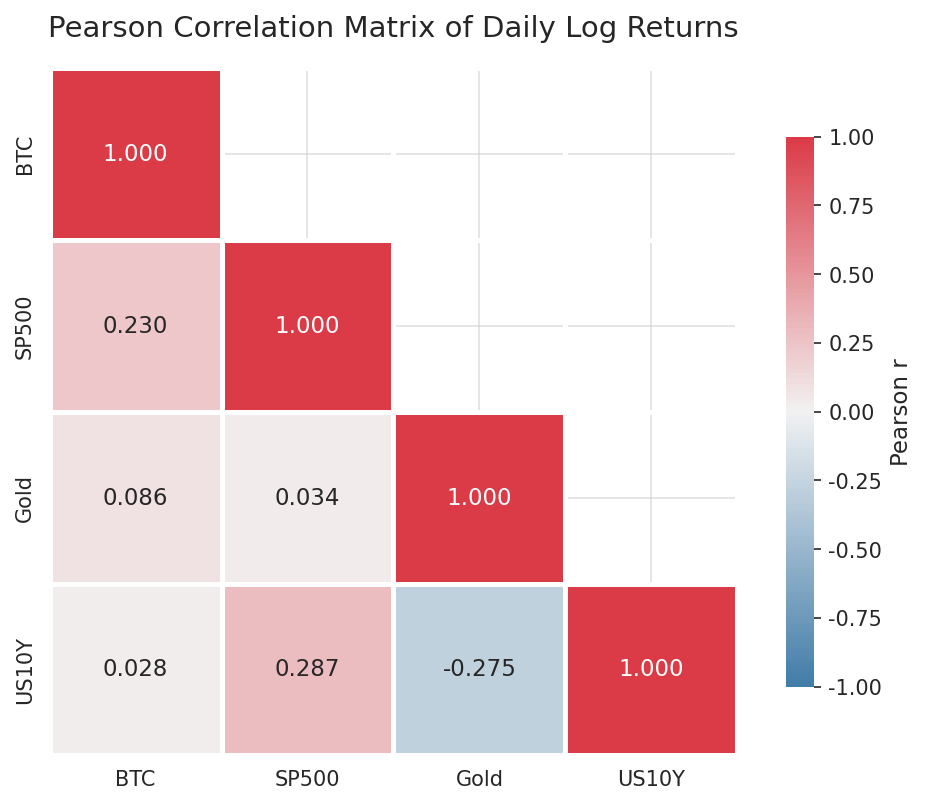

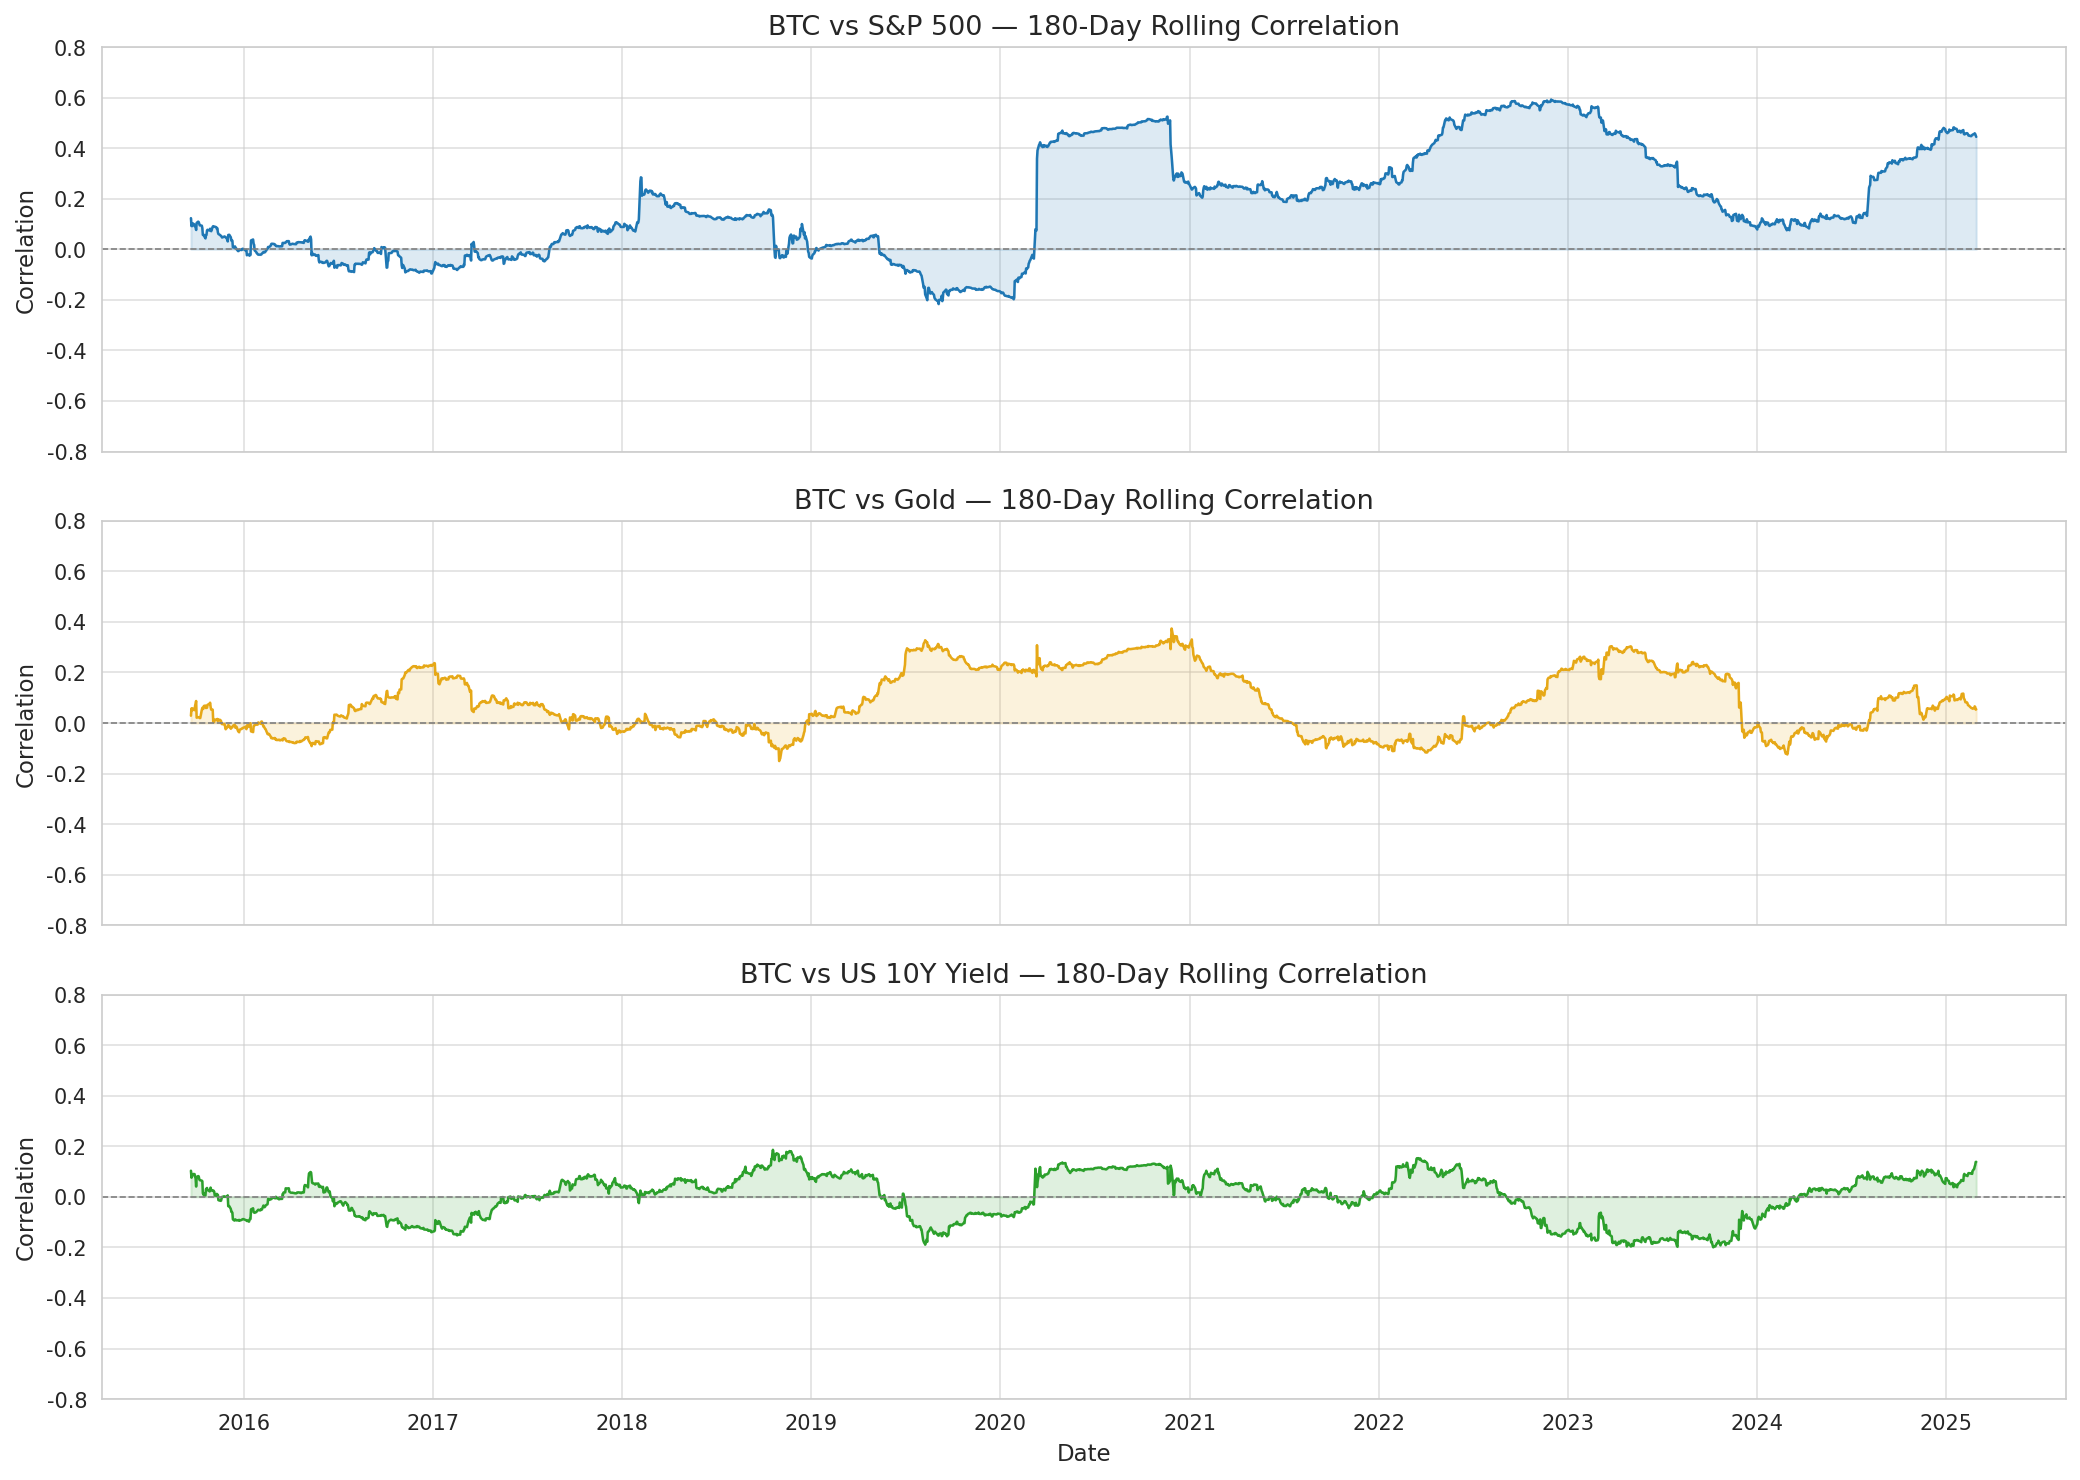

Jarque-Bera Normality Test (H0: returns are normally distributed)
       JB Statistic    p-value Conclusion (α=0.05)
Asset                                             
BTC         9327.23   0.00e+00           Reject H0
SP500      26387.21   0.00e+00           Reject H0
Gold        1407.60  2.20e-306           Reject H0
US10Y     102371.81   0.00e+00           Reject H0



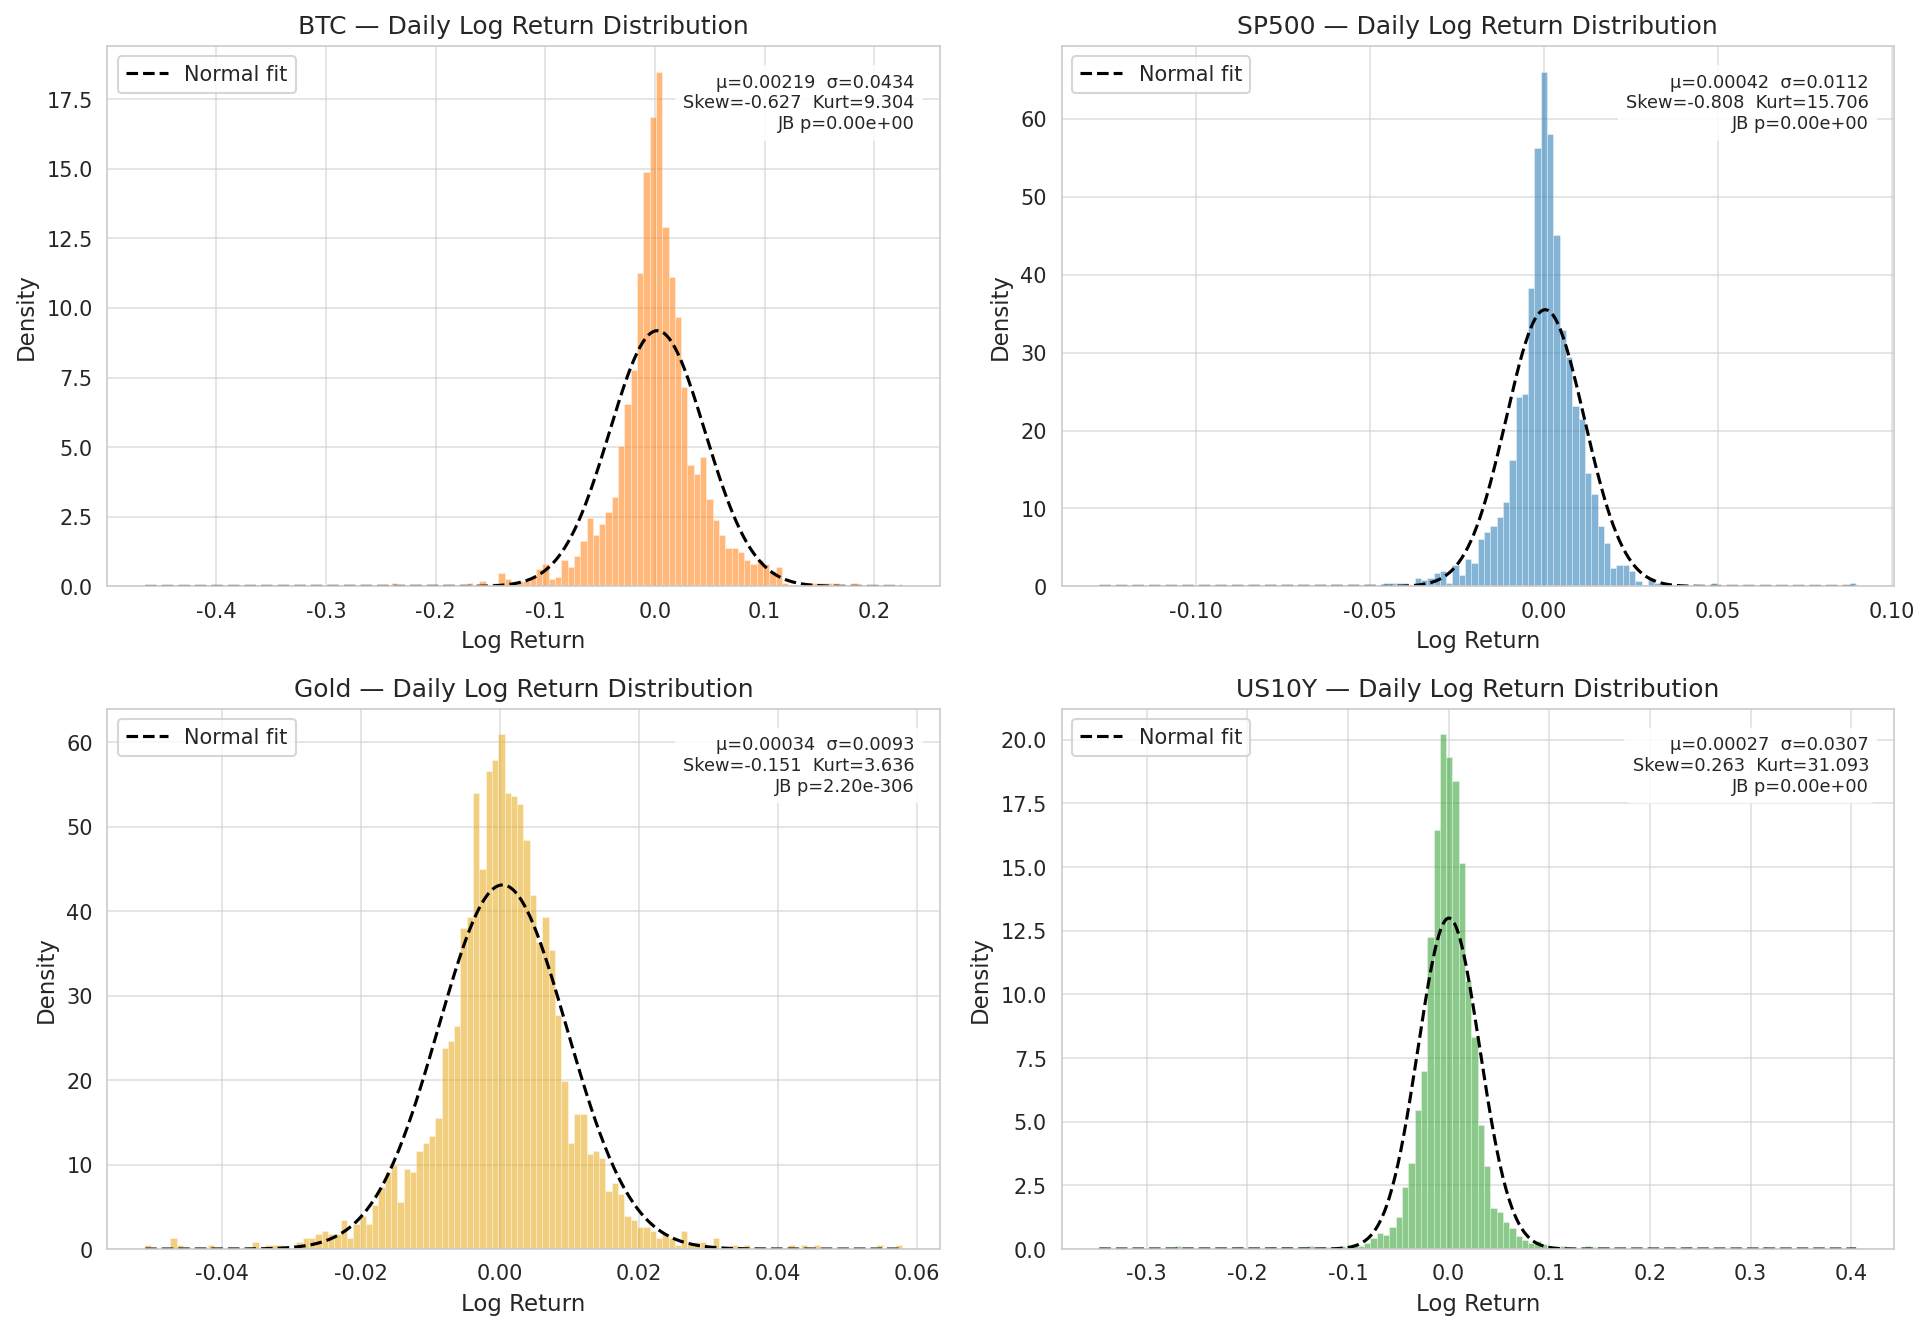

All charts saved. Done!


In [4]:
# ============================================================
# Multi-Asset Return Analysis
# Descriptive Stats / Correlation / Rolling Correlation / JB Test
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ---------- 0. 全局绘图风格 ----------
plt.rcParams.update({
    "figure.dpi": 150,
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.facecolor": "white",
})
sns.set_style("whitegrid")

TRADING_DAYS = 252  # 年化交易日数

# ---------- 1. 读取数据 ----------
df = pd.read_csv("multi_asset_log_returns.csv", index_col=0, parse_dates=True)
assets = df.columns.tolist()
print(f"Assets: {assets}")
print(f"Date range: {df.index[0].date()} ~ {df.index[-1].date()}")
print(f"Total observations: {len(df)}\n")

# ============================================================
# PART 1 — 描述性统计
# ============================================================
desc = pd.DataFrame(index=assets)

# 年化收益率 = 日均对数收益率 × 252
desc["Ann. Return (%)"] = df.mean() * TRADING_DAYS * 100

# 年化波动率 = 日标准差 × sqrt(252)
desc["Ann. Vol (%)"] = df.std() * np.sqrt(TRADING_DAYS) * 100

# 夏普比率（无风险利率假设为 0）
desc["Sharpe Ratio"] = (df.mean() * TRADING_DAYS) / (df.std() * np.sqrt(TRADING_DAYS))

# 偏度和峰度
desc["Skewness"] = df.skew()
desc["Kurtosis"] = df.kurtosis()  # 超额峰度（正态分布 = 0）

# 最大单日涨跌
desc["Max Daily (%)"] = df.max() * 100
desc["Min Daily (%)"] = df.min() * 100

print("=" * 70)
print("Descriptive Statistics")
print("=" * 70)
print(desc.round(4).to_string())
print()

# 导出为 CSV
desc.round(4).to_csv("descriptive_statistics.csv")

# ============================================================
# PART 2 — Pearson 相关性矩阵热力图
# ============================================================
corr_matrix = df.corr(method="pearson")

fig, ax = plt.subplots(figsize=(7, 5.5))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # 上三角遮罩

cmap = sns.diverging_palette(240, 10, as_cmap=True)
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".3f",
    cmap=cmap,
    vmin=-1, vmax=1,
    center=0,
    square=True,
    linewidths=1.5,
    cbar_kws={"shrink": 0.8, "label": "Pearson r"},
    ax=ax,
)
ax.set_title("Pearson Correlation Matrix of Daily Log Returns", pad=15)
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

# ============================================================
# PART 3 — 180 天滚动相关系数
# ============================================================
WINDOW = 180

rolling_btc_sp500 = df["BTC"].rolling(WINDOW).corr(df["SP500"])
rolling_btc_gold = df["BTC"].rolling(WINDOW).corr(df["Gold"])
rolling_btc_us10y = df["BTC"].rolling(WINDOW).corr(df["US10Y"])

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# --- BTC vs SP500 ---
ax1 = axes[0]
ax1.plot(rolling_btc_sp500.index, rolling_btc_sp500, color="#1f77b4", linewidth=1.2)
ax1.axhline(y=0, color="grey", linestyle="--", linewidth=0.8)
ax1.fill_between(rolling_btc_sp500.index, rolling_btc_sp500, 0, alpha=0.15, color="#1f77b4")
ax1.set_ylabel("Correlation")
ax1.set_title(f"BTC vs S&P 500 — {WINDOW}-Day Rolling Correlation", fontsize=13)
ax1.set_ylim(-0.8, 0.8)

# --- BTC vs Gold ---
ax2 = axes[1]
ax2.plot(rolling_btc_gold.index, rolling_btc_gold, color="#e6a817", linewidth=1.2)
ax2.axhline(y=0, color="grey", linestyle="--", linewidth=0.8)
ax2.fill_between(rolling_btc_gold.index, rolling_btc_gold, 0, alpha=0.15, color="#e6a817")
ax2.set_ylabel("Correlation")
ax2.set_title(f"BTC vs Gold — {WINDOW}-Day Rolling Correlation", fontsize=13)
ax2.set_ylim(-0.8, 0.8)

# --- BTC vs US10Y ---
ax3 = axes[2]
ax3.plot(rolling_btc_us10y.index, rolling_btc_us10y, color="#2ca02c", linewidth=1.2)
ax3.axhline(y=0, color="grey", linestyle="--", linewidth=0.8)
ax3.fill_between(rolling_btc_us10y.index, rolling_btc_us10y, 0, alpha=0.15, color="#2ca02c")
ax3.set_ylabel("Correlation")
ax3.set_title(f"BTC vs US 10Y Yield — {WINDOW}-Day Rolling Correlation", fontsize=13)
ax3.set_ylim(-0.8, 0.8)
ax3.set_xlabel("Date")

plt.tight_layout()
plt.savefig("rolling_correlation.png", dpi=200, bbox_inches="tight")
plt.show()

# ============================================================
# PART 4 — Jarque-Bera 正态性检验
# ============================================================
print("=" * 70)
print("Jarque-Bera Normality Test (H0: returns are normally distributed)")
print("=" * 70)

jb_results = []
for asset in assets:
    jb_stat, jb_pvalue = stats.jarque_bera(df[asset])
    is_normal = "Fail to Reject H0" if jb_pvalue > 0.05 else "Reject H0"
    jb_results.append({
        "Asset": asset,
        "JB Statistic": round(jb_stat, 2),
        "p-value": f"{jb_pvalue:.2e}",
        "Conclusion (α=0.05)": is_normal,
    })

jb_df = pd.DataFrame(jb_results).set_index("Asset")
print(jb_df.to_string())
print()

# ============================================================
# BONUS — 收益率分布直方图 + 正态拟合曲线
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
colors = ["#ff7f0e", "#1f77b4", "#e6a817", "#2ca02c"]

for idx, (asset, color) in enumerate(zip(assets, colors)):
    ax = axes[idx // 2][idx % 2]
    data = df[asset].dropna()

    # 直方图
    ax.hist(data, bins=120, density=True, alpha=0.55, color=color, edgecolor="white", linewidth=0.3)

    # 正态拟合曲线
    mu, sigma = data.mean(), data.std()
    x_range = np.linspace(data.min(), data.max(), 500)
    ax.plot(x_range, stats.norm.pdf(x_range, mu, sigma), "k--", linewidth=1.5, label="Normal fit")

    # 标注统计量
    jb_stat, jb_p = stats.jarque_bera(data)
    text = f"μ={mu:.5f}  σ={sigma:.4f}\nSkew={data.skew():.3f}  Kurt={data.kurtosis():.3f}\nJB p={jb_p:.2e}"
    ax.text(0.97, 0.95, text, transform=ax.transAxes, fontsize=8.5,
            verticalalignment="top", horizontalalignment="right",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.85))

    ax.set_title(f"{asset} — Daily Log Return Distribution", fontsize=12)
    ax.set_xlabel("Log Return")
    ax.set_ylabel("Density")
    ax.legend(loc="upper left")

plt.tight_layout()
plt.savefig("return_distributions.png", dpi=200, bbox_inches="tight")
plt.show()

print("All charts saved. Done!")


Assets: ['BTC', 'SP500', 'Gold', 'US10Y']
Period: 2015-01-05 ~ 2025-02-28
Observations: 2551

SAFE-HAVEN TEST (worst 5% days of SP500)
Threshold daily return: -0.0171 (-1.71%)
Stress days: 128 | Normal days: 2423

  BTC:
    Avg return on stress days: -2.9046%
    Avg return on normal days: +0.3842%
    t-stat=-4.493, p-value=0.0000
    → NOT safe haven ✗

  Gold:
    Avg return on stress days: +0.0877%
    Avg return on normal days: +0.0314%
    t-stat=0.778, p-value=0.4382
    → SAFE HAVEN ✓



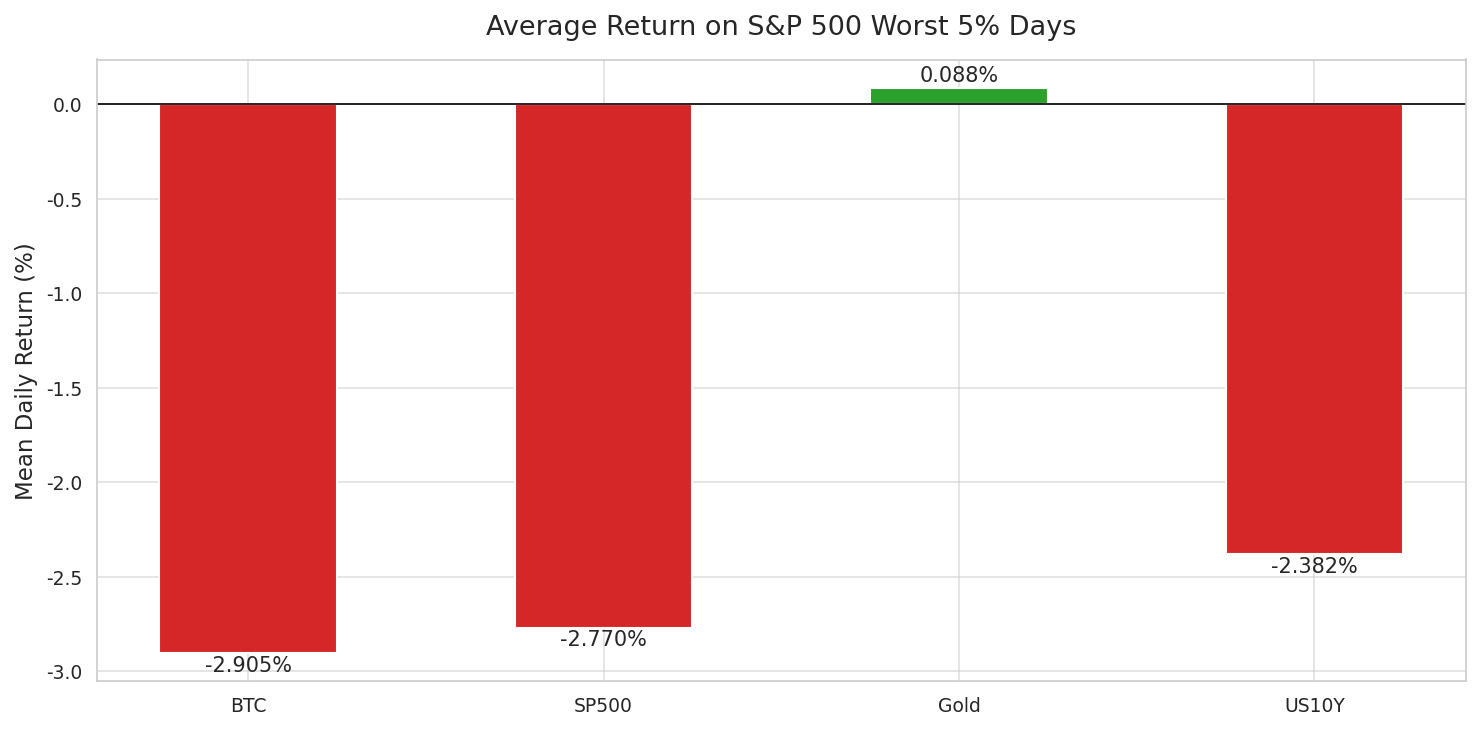

Column order: ['BTC', 'SP500', 'Gold', 'US10Y']

Portfolio A weights: {'BTC': np.float64(0.0), 'SP500': np.float64(0.6), 'Gold': np.float64(0.0), 'US10Y': np.float64(0.4)}
Portfolio B weights: {'BTC': np.float64(0.1), 'SP500': np.float64(0.55), 'Gold': np.float64(0.0), 'US10Y': np.float64(0.35)}

PORTFOLIO PERFORMANCE COMPARISON
                      Ann. Return (%)  Ann. Volatility (%)  Sharpe Ratio  Sortino Ratio  Max Drawdown (%)
Name                                                                                                     
A: 60/40 Traditional             9.02                24.78        0.3641         0.4363            -54.01
B: 55/35/10 w/ BTC              13.68                23.84        0.5738         0.6875            -49.19



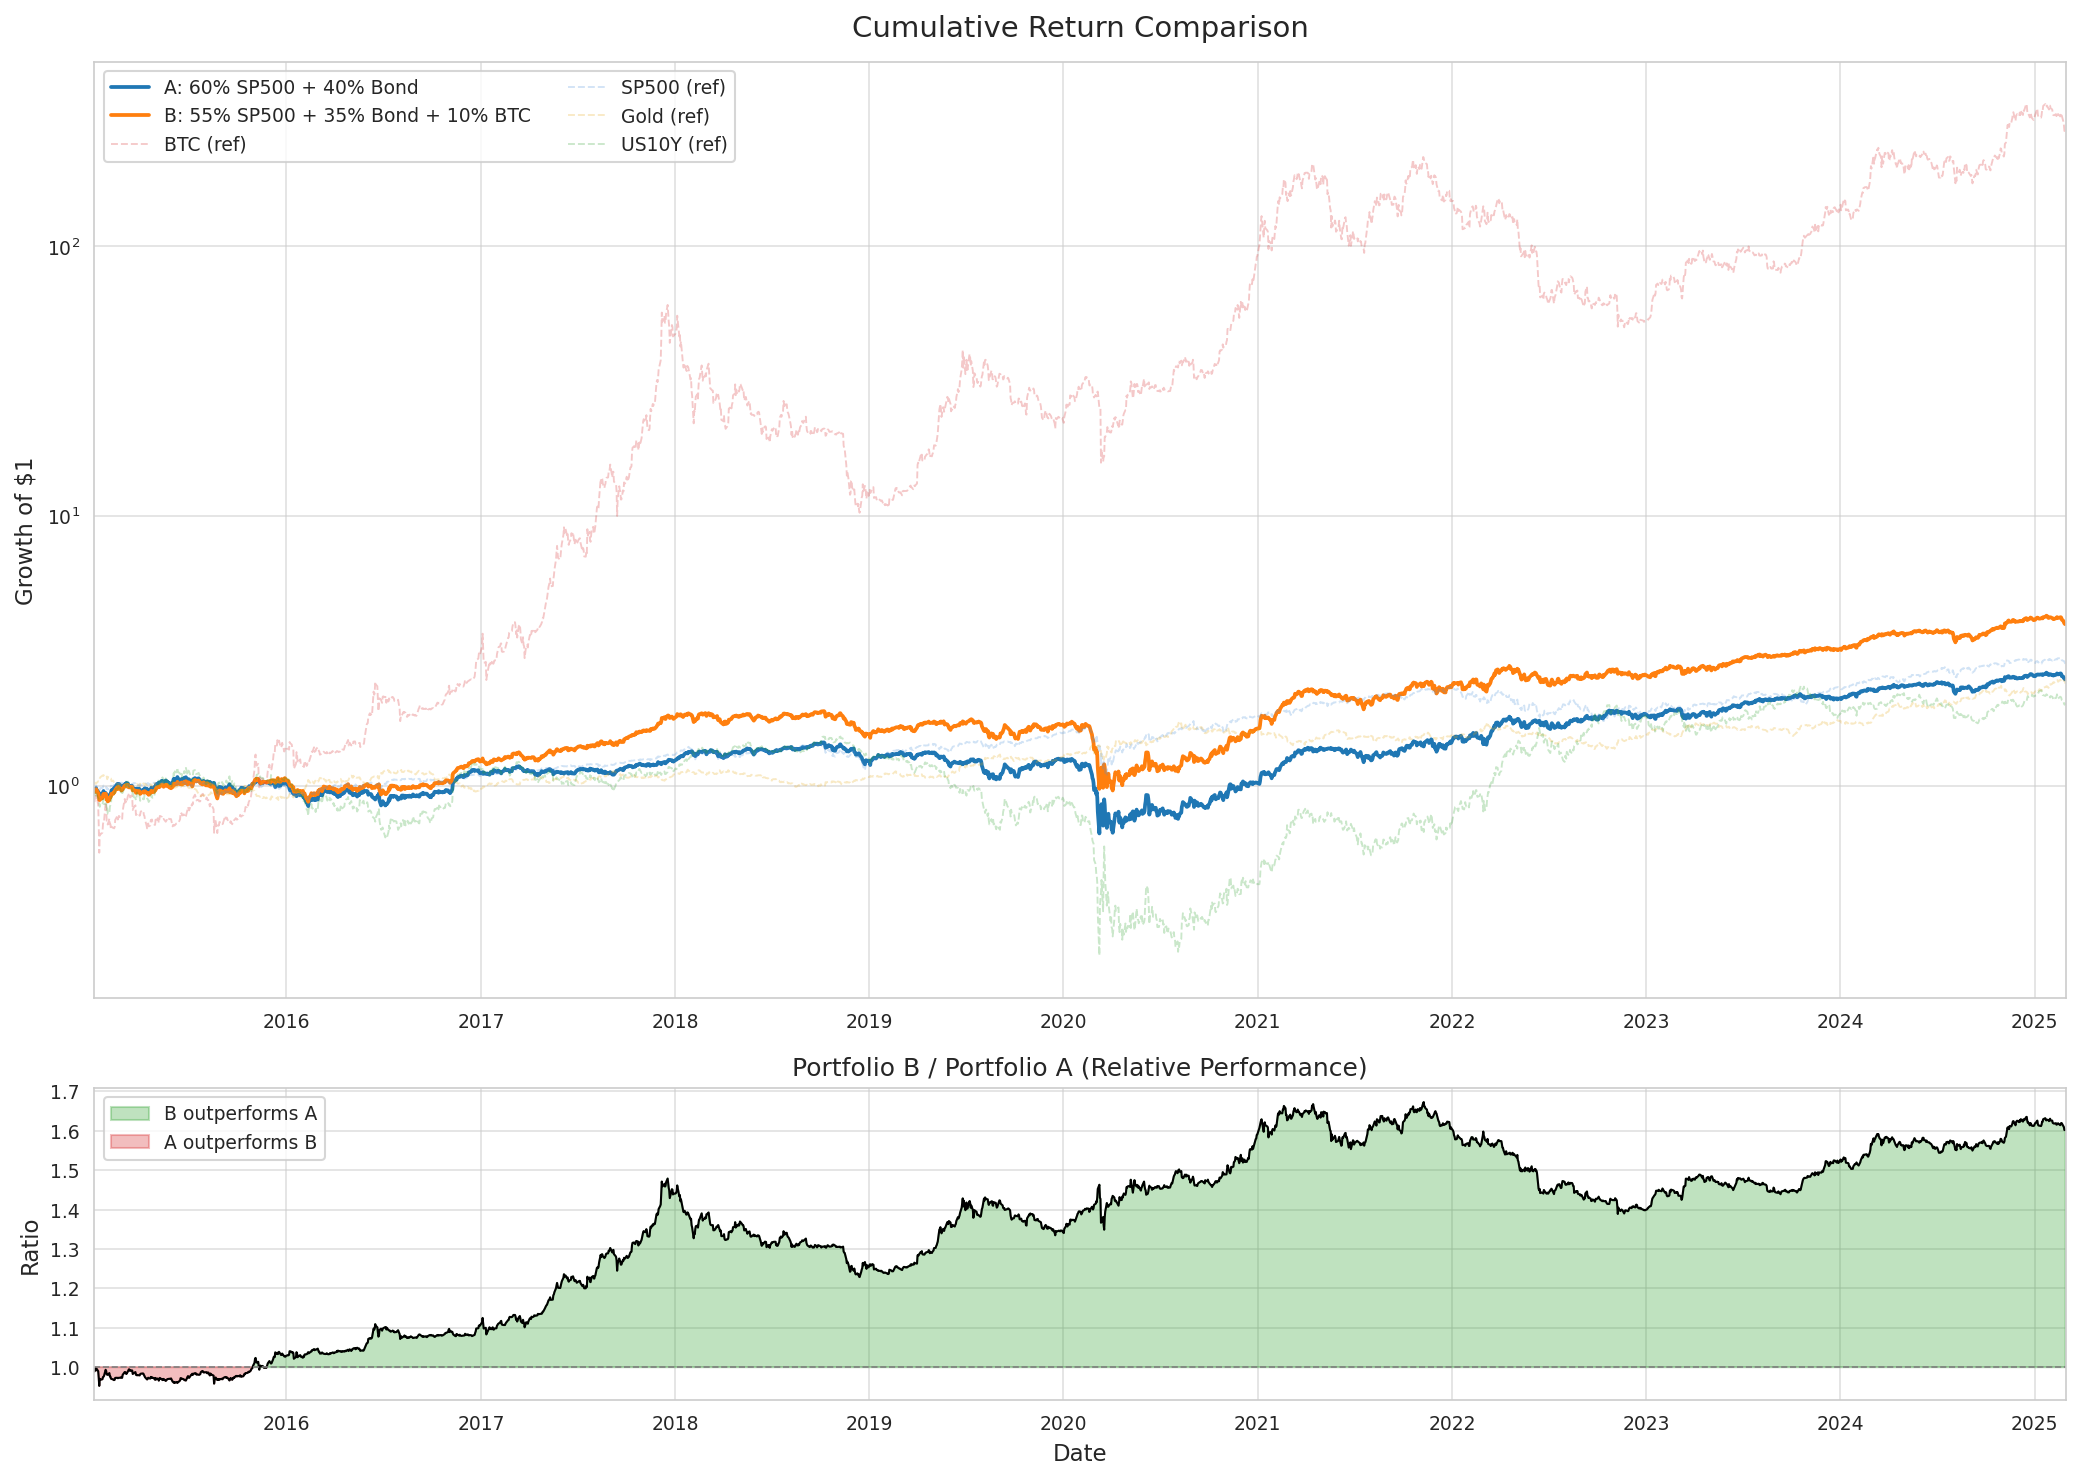

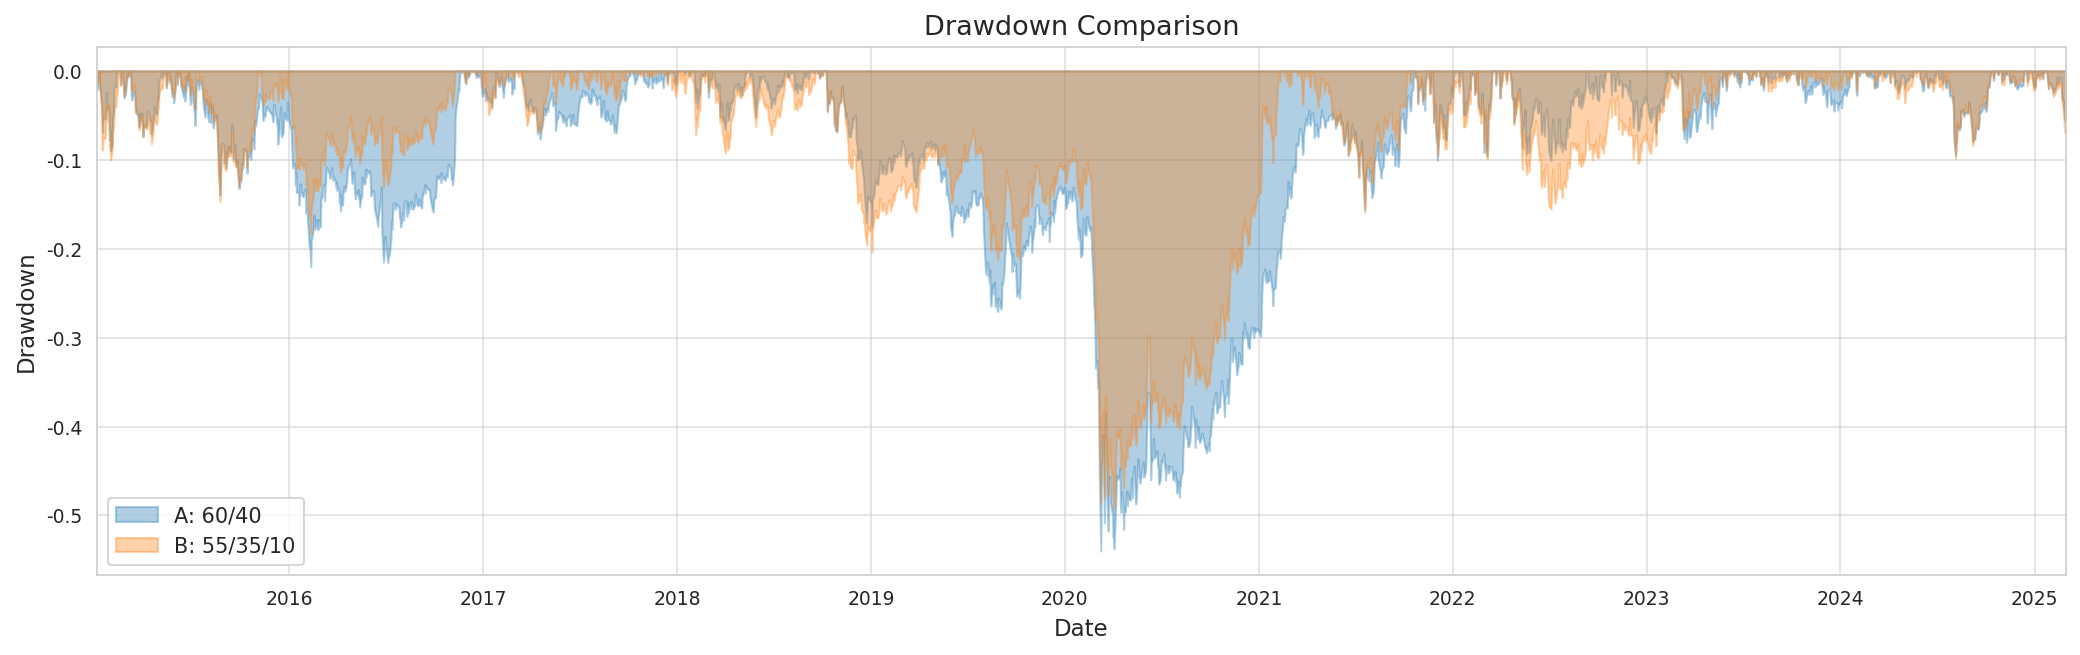

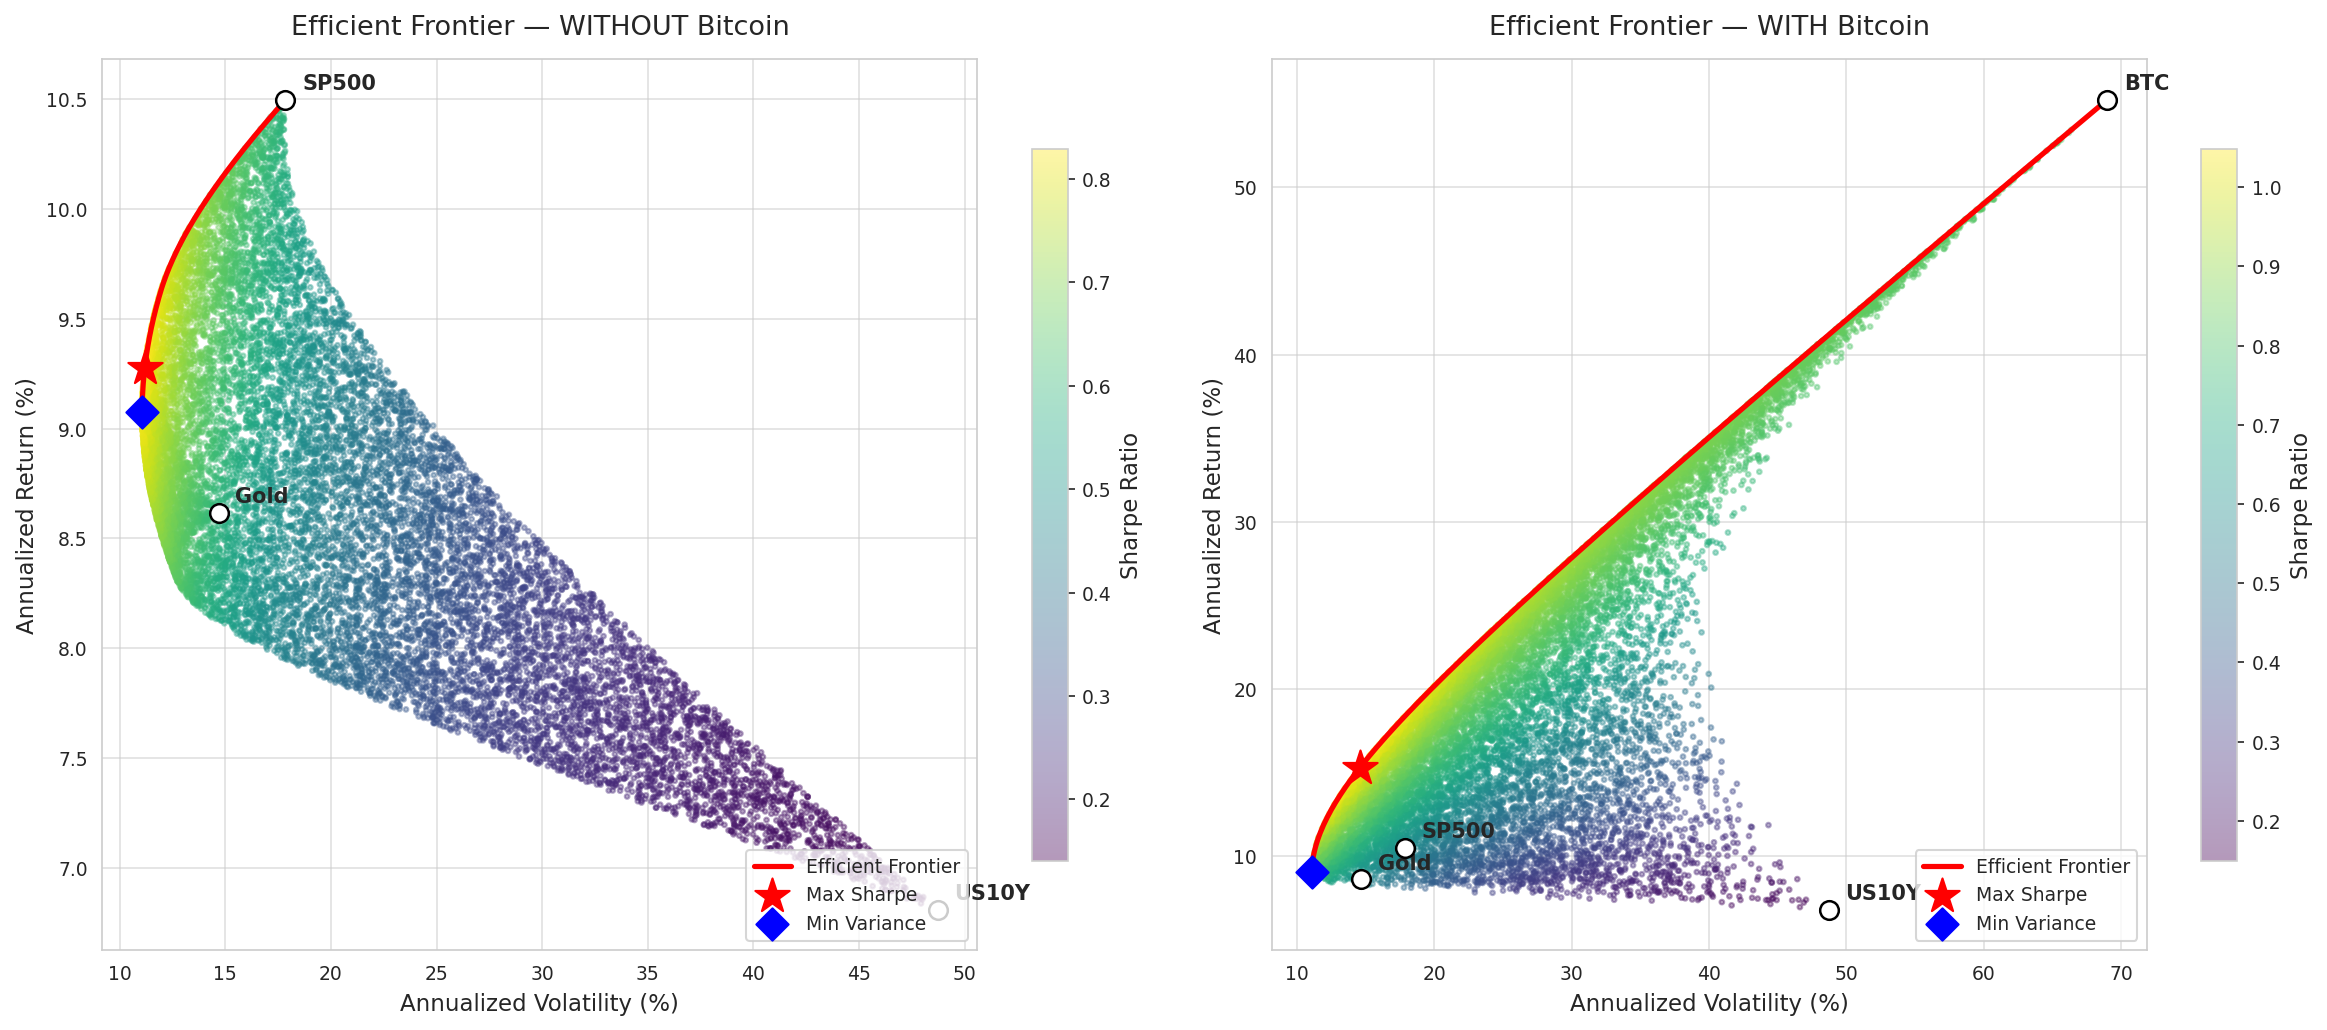

OPTIMAL PORTFOLIO WEIGHTS

--- Without BTC ---
  Max Sharpe weights:
       SP500: 39.44%
        Gold: 56.18%
       US10Y: 4.38%
    Sharpe = 0.8295
  Min Variance weights:
       SP500: 31.18%
        Gold: 61.78%
       US10Y: 7.04%

--- With BTC ---
  Max Sharpe weights:
         BTC: 13.32%
       SP500: 28.53%
        Gold: 53.28%
       US10Y: 4.87%
    Sharpe = 1.0493
  Min Variance weights:
         BTC: 0.00%
       SP500: 31.23%
        Gold: 61.79%
       US10Y: 6.98%

ANALYSIS COMPLETE — All charts saved.


In [5]:
# ============================================================
# Modern Portfolio Theory — Empirical Analysis
# Safe-Haven Test / Portfolio Construction / Efficient Frontier
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from scipy import stats

# ---------- 全局设置 ----------
plt.rcParams.update({
    "figure.dpi": 150, "axes.titlesize": 13, "axes.labelsize": 11,
    "xtick.labelsize": 9, "ytick.labelsize": 9, "legend.fontsize": 10,
    "figure.facecolor": "white",
})
sns.set_style("whitegrid")

TRADING_DAYS = 252
RF = 0.0  # 无风险利率假设为 0

# ============================================================
# 0. 加载数据
# ============================================================
df = pd.read_csv("multi_asset_log_returns.csv", index_col=0, parse_dates=True)
print(f"Assets: {df.columns.tolist()}")
print(f"Period: {df.index[0].date()} ~ {df.index[-1].date()}")
print(f"Observations: {len(df)}\n")


# ============================================================
# PART 1 — 避险属性检验（Safe-Haven Effect）
# ============================================================
def safe_haven_test(returns_df, stress_asset="SP500", test_assets=None, quantile=0.05):
    """
    找出 stress_asset 表现最差的 quantile 分位日期，
    检验 test_assets 在这些极端日期的平均收益是否显著异于零。
    """
    if test_assets is None:
        test_assets = ["BTC", "Gold"]

    threshold = returns_df[stress_asset].quantile(quantile)
    stress_dates = returns_df[returns_df[stress_asset] <= threshold].index
    normal_dates = returns_df[returns_df[stress_asset] > threshold].index

    print("=" * 70)
    print(f"SAFE-HAVEN TEST (worst {quantile:.0%} days of {stress_asset})")
    print(f"Threshold daily return: {threshold:.4f} ({threshold*100:.2f}%)")
    print(f"Stress days: {len(stress_dates)} | Normal days: {len(normal_dates)}")
    print("=" * 70)

    results = []
    for asset in test_assets:
        stress_ret = returns_df.loc[stress_dates, asset]
        normal_ret = returns_df.loc[normal_dates, asset]

        # 单样本 t 检验：极端日期均值是否显著不为零
        t_stat, p_value = stats.ttest_1samp(stress_ret, 0)

        mean_stress = stress_ret.mean()
        mean_normal = normal_ret.mean()
        verdict = "SAFE HAVEN ✓" if mean_stress > 0 else "NOT safe haven ✗"

        results.append({
            "Asset": asset,
            "Mean (Stress Days)": f"{mean_stress:.6f}",
            "Mean (Normal Days)": f"{mean_normal:.6f}",
            "t-stat": f"{t_stat:.3f}",
            "p-value": f"{p_value:.4f}",
            "Verdict": verdict,
        })
        print(f"\n  {asset}:")
        print(f"    Avg return on stress days: {mean_stress*100:+.4f}%")
        print(f"    Avg return on normal days: {mean_normal*100:+.4f}%")
        print(f"    t-stat={t_stat:.3f}, p-value={p_value:.4f}")
        print(f"    → {verdict}")

    print()
    return pd.DataFrame(results).set_index("Asset"), stress_dates


safe_haven_df, stress_dates = safe_haven_test(df)

# 可视化：极端日期各资产表现
fig, ax = plt.subplots(figsize=(10, 5))
stress_means = df.loc[stress_dates].mean() * 100
colors = ["#d62728" if v < 0 else "#2ca02c" for v in stress_means]
bars = ax.bar(stress_means.index, stress_means.values, color=colors, edgecolor="white", width=0.5)
ax.axhline(0, color="black", linewidth=0.8)
for bar, val in zip(bars, stress_means.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01 * np.sign(val),
            f"{val:.3f}%", ha="center", va="bottom" if val > 0 else "top", fontsize=10)
ax.set_title("Average Return on S&P 500 Worst 5% Days", pad=12)
ax.set_ylabel("Mean Daily Return (%)")
plt.tight_layout()
plt.savefig("safe_haven_test.png", dpi=200, bbox_inches="tight")
plt.show()


# ============================================================
# PART 2 & 3 — 投资组合构建与绩效对比
# ============================================================

# --- 辅助函数 ---
def portfolio_cumulative(returns_df, weights, name="Portfolio"):
    """计算组合的每日对数收益 → 累积净值曲线"""
    port_ret = (returns_df * weights).sum(axis=1)
    cum_ret = np.exp(port_ret.cumsum())  # 对数收益累积 → 净值
    return port_ret, cum_ret


def max_drawdown(cum_series):
    """最大回撤"""
    running_max = cum_series.cummax()
    drawdown = (cum_series - running_max) / running_max
    return drawdown.min()


def portfolio_metrics(port_ret, cum_ret, name="Portfolio"):
    """计算年化收益、波动率、夏普比率、最大回撤"""
    ann_ret = port_ret.mean() * TRADING_DAYS
    ann_vol = port_ret.std() * np.sqrt(TRADING_DAYS)
    sharpe = (ann_ret - RF) / ann_vol
    mdd = max_drawdown(cum_ret)
    # Sortino: 仅用下行波动率
    downside = port_ret[port_ret < 0].std() * np.sqrt(TRADING_DAYS)
    sortino = (ann_ret - RF) / downside if downside > 0 else np.nan
    return {
        "Name": name,
        "Ann. Return (%)": round(ann_ret * 100, 2),
        "Ann. Volatility (%)": round(ann_vol * 100, 2),
        "Sharpe Ratio": round(sharpe, 4),
        "Sortino Ratio": round(sortino, 4),
        "Max Drawdown (%)": round(mdd * 100, 2),
    }


# --- 定义组合权重（按列顺序: BTC, SP500, Gold, US10Y） ---
# 确认列顺序
asset_order = df.columns.tolist()
print(f"Column order: {asset_order}")

# 构造权重字典 → 按 df 列顺序映射
def make_weights(weight_dict):
    """将 {asset: weight} 字典按 df 列顺序转为 numpy array"""
    return np.array([weight_dict.get(col, 0.0) for col in asset_order])


w_A = make_weights({"SP500": 0.60, "US10Y": 0.40})
w_B = make_weights({"SP500": 0.55, "US10Y": 0.35, "BTC": 0.10})

print(f"\nPortfolio A weights: {dict(zip(asset_order, w_A))}")
print(f"Portfolio B weights: {dict(zip(asset_order, w_B))}")

# 计算各组合
ret_A, cum_A = portfolio_cumulative(df, w_A, "Portfolio A")
ret_B, cum_B = portfolio_cumulative(df, w_B, "Portfolio B")

# 单独计算各资产累积净值用于参考
cum_assets = np.exp(df.cumsum())

metrics_A = portfolio_metrics(ret_A, cum_A, "A: 60/40 Traditional")
metrics_B = portfolio_metrics(ret_B, cum_B, "B: 55/35/10 w/ BTC")

comparison_df = pd.DataFrame([metrics_A, metrics_B]).set_index("Name")
print("\n" + "=" * 70)
print("PORTFOLIO PERFORMANCE COMPARISON")
print("=" * 70)
print(comparison_df.to_string())
print()
comparison_df.to_csv("portfolio_comparison.csv")

# --- 绘制累积收益曲线 ---
fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={"height_ratios": [3, 1]})

# 上图：累积净值
ax1 = axes[0]
ax1.plot(cum_A.index, cum_A, label="A: 60% SP500 + 40% Bond", color="#1f77b4", linewidth=1.8)
ax1.plot(cum_B.index, cum_B, label="B: 55% SP500 + 35% Bond + 10% BTC",
         color="#ff7f0e", linewidth=1.8)
# 添加各资产参考线（半透明）
asset_colors = {"BTC": "#d62728", "SP500": "#4a90d9", "Gold": "#e6a817", "US10Y": "#2ca02c"}
for asset in asset_order:
    ax1.plot(cum_assets.index, cum_assets[asset], alpha=0.25, linewidth=0.9,
             color=asset_colors.get(asset, "grey"), linestyle="--", label=f"{asset} (ref)")

ax1.set_title("Cumulative Return Comparison", fontsize=14, pad=12)
ax1.set_ylabel("Growth of $1")
ax1.legend(loc="upper left", fontsize=9, ncol=2)
ax1.set_yscale("log")
ax1.set_xlim(df.index[0], df.index[-1])

# 下图：组合 B 相对组合 A 的超额累积收益
excess = cum_B / cum_A
ax2 = axes[1]
ax2.fill_between(excess.index, 1, excess, where=(excess >= 1),
                 alpha=0.3, color="#2ca02c", label="B outperforms A")
ax2.fill_between(excess.index, 1, excess, where=(excess < 1),
                 alpha=0.3, color="#d62728", label="A outperforms B")
ax2.plot(excess.index, excess, color="black", linewidth=1)
ax2.axhline(1, color="grey", linewidth=0.8, linestyle="--")
ax2.set_title("Portfolio B / Portfolio A (Relative Performance)", fontsize=12)
ax2.set_ylabel("Ratio")
ax2.set_xlabel("Date")
ax2.legend(loc="upper left", fontsize=9)
ax2.set_xlim(df.index[0], df.index[-1])

plt.tight_layout()
plt.savefig("portfolio_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

# --- 回撤曲线 ---
def drawdown_series(cum):
    return (cum - cum.cummax()) / cum.cummax()

fig, ax = plt.subplots(figsize=(14, 4.5))
dd_A = drawdown_series(cum_A)
dd_B = drawdown_series(cum_B)
ax.fill_between(dd_A.index, dd_A, 0, alpha=0.35, color="#1f77b4", label="A: 60/40")
ax.fill_between(dd_B.index, dd_B, 0, alpha=0.35, color="#ff7f0e", label="B: 55/35/10")
ax.set_title("Drawdown Comparison", fontsize=13)
ax.set_ylabel("Drawdown")
ax.set_xlabel("Date")
ax.legend()
ax.set_xlim(df.index[0], df.index[-1])
plt.tight_layout()
plt.savefig("drawdown_comparison.png", dpi=200, bbox_inches="tight")
plt.show()


# ============================================================
# PART 4 — 有效边界 (Efficient Frontier)
# ============================================================

def efficient_frontier(returns_df, asset_names, n_points=200, n_random=15000):
    """
    用优化方法绘制有效边界，同时叠加蒙特卡洛随机组合散点。
    返回：frontier_vols, frontier_rets, random_vols, random_rets, random_sharpes
    """
    mean_ret = returns_df[asset_names].mean().values * TRADING_DAYS
    cov_mat = returns_df[asset_names].cov().values * TRADING_DAYS
    n_assets = len(asset_names)

    # --- 蒙特卡洛随机组合 ---
    rng = np.random.default_rng(42)
    rand_weights = rng.dirichlet(np.ones(n_assets), n_random)
    rand_rets = rand_weights @ mean_ret
    rand_vols = np.array([np.sqrt(w @ cov_mat @ w) for w in rand_weights])
    rand_sharpes = (rand_rets - RF) / rand_vols

    # --- 优化求有效边界 ---
    def port_vol(w):
        return np.sqrt(w @ cov_mat @ w)

    def port_ret(w):
        return w @ mean_ret

    constraints = [{"type": "eq", "fun": lambda w: np.sum(w) - 1}]
    bounds = tuple((0, 1) for _ in range(n_assets))  # 禁止做空

    # 求最小方差组合和最大收益以确定扫描范围
    res_min_vol = minimize(port_vol, np.ones(n_assets) / n_assets,
                           method="SLSQP", bounds=bounds, constraints=constraints)
    min_vol_ret = port_ret(res_min_vol.x)
    max_ret = np.max(mean_ret)

    target_rets = np.linspace(min_vol_ret, max_ret, n_points)
    frontier_vols = []
    frontier_rets = []

    for target in target_rets:
        cons = [
            {"type": "eq", "fun": lambda w: np.sum(w) - 1},
            {"type": "eq", "fun": lambda w, t=target: port_ret(w) - t},
        ]
        res = minimize(port_vol, np.ones(n_assets) / n_assets,
                       method="SLSQP", bounds=bounds, constraints=cons)
        if res.success:
            frontier_vols.append(res.fun)
            frontier_rets.append(target)

    # 最大夏普组合
    def neg_sharpe(w):
        r = port_ret(w)
        v = port_vol(w)
        return -(r - RF) / v

    res_max_sharpe = minimize(neg_sharpe, np.ones(n_assets) / n_assets,
                              method="SLSQP", bounds=bounds, constraints=constraints)
    ms_ret = port_ret(res_max_sharpe.x)
    ms_vol = port_vol(res_max_sharpe.x)
    ms_weights = res_max_sharpe.x

    return {
        "frontier_vols": np.array(frontier_vols),
        "frontier_rets": np.array(frontier_rets),
        "rand_vols": rand_vols,
        "rand_rets": rand_rets,
        "rand_sharpes": rand_sharpes,
        "ms_vol": ms_vol,
        "ms_ret": ms_ret,
        "ms_weights": ms_weights,
        "mv_vol": res_min_vol.fun,
        "mv_ret": min_vol_ret,
        "mv_weights": res_min_vol.x,
        "asset_names": asset_names,
    }


# 不含 BTC 的有效边界（SP500, Gold, US10Y）
assets_no_btc = ["SP500", "Gold", "US10Y"]
ef_no_btc = efficient_frontier(df, assets_no_btc)

# 含 BTC 的有效边界（BTC, SP500, Gold, US10Y）
assets_with_btc = ["BTC", "SP500", "Gold", "US10Y"]
ef_with_btc = efficient_frontier(df, assets_with_btc)

# --- 绘图 ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, ef, title_suffix in zip(
    axes,
    [ef_no_btc, ef_with_btc],
    ["WITHOUT Bitcoin", "WITH Bitcoin"]
):
    sc = ax.scatter(ef["rand_vols"] * 100, ef["rand_rets"] * 100,
                    c=ef["rand_sharpes"], cmap="viridis", s=5, alpha=0.4)
    ax.plot(ef["frontier_vols"] * 100, ef["frontier_rets"] * 100,
            "r-", linewidth=2.5, label="Efficient Frontier")
    ax.scatter(ef["ms_vol"] * 100, ef["ms_ret"] * 100,
               marker="*", s=300, c="red", zorder=5, label="Max Sharpe")
    ax.scatter(ef["mv_vol"] * 100, ef["mv_ret"] * 100,
               marker="D", s=120, c="blue", zorder=5, label="Min Variance")

    # 标注各资产位置
    mean_rets = df[ef["asset_names"]].mean().values * TRADING_DAYS
    vols = df[ef["asset_names"]].std().values * np.sqrt(TRADING_DAYS)
    for i, name in enumerate(ef["asset_names"]):
        ax.scatter(vols[i] * 100, mean_rets[i] * 100, marker="o", s=80,
                   edgecolors="black", linewidths=1.2, zorder=5, c="white")
        ax.annotate(name, (vols[i] * 100, mean_rets[i] * 100),
                    textcoords="offset points", xytext=(8, 5), fontsize=10, fontweight="bold")

    ax.set_title(f"Efficient Frontier — {title_suffix}", fontsize=13, pad=12)
    ax.set_xlabel("Annualized Volatility (%)")
    ax.set_ylabel("Annualized Return (%)")
    ax.legend(loc="lower right", fontsize=9)
    plt.colorbar(sc, ax=ax, label="Sharpe Ratio", shrink=0.8)

plt.tight_layout()
plt.savefig("efficient_frontier.png", dpi=200, bbox_inches="tight")
plt.show()

# 输出最优组合权重
print("=" * 70)
print("OPTIMAL PORTFOLIO WEIGHTS")
print("=" * 70)
for label, ef in [("Without BTC", ef_no_btc), ("With BTC", ef_with_btc)]:
    print(f"\n--- {label} ---")
    print(f"  Max Sharpe weights:")
    for name, w in zip(ef["asset_names"], ef["ms_weights"]):
        print(f"    {name:>8s}: {w:.2%}")
    print(f"    Sharpe = {(ef['ms_ret'] - RF) / ef['ms_vol']:.4f}")
    print(f"  Min Variance weights:")
    for name, w in zip(ef["asset_names"], ef["mv_weights"]):
        print(f"    {name:>8s}: {w:.2%}")

print("\n" + "=" * 70)
print("ANALYSIS COMPLETE — All charts saved.")
print("=" * 70)

